# Project — Chapter 89: Cellular Automata

> **Prerequisites:** ch062 (Piecewise), ch076 (Dynamical Systems), ch063 (Step Functions)
>
> **Concepts:** Rule-based dynamics, 1D/2D CA, Conway's Game of Life, emergent behavior
>
> **Output:** Full cellular automaton simulator for 1D elementary CA and 2D Game of Life
>
> **Difficulty:** Intermediate | ~50 minutes

---

## Stage 1 — 1D Elementary Cellular Automata

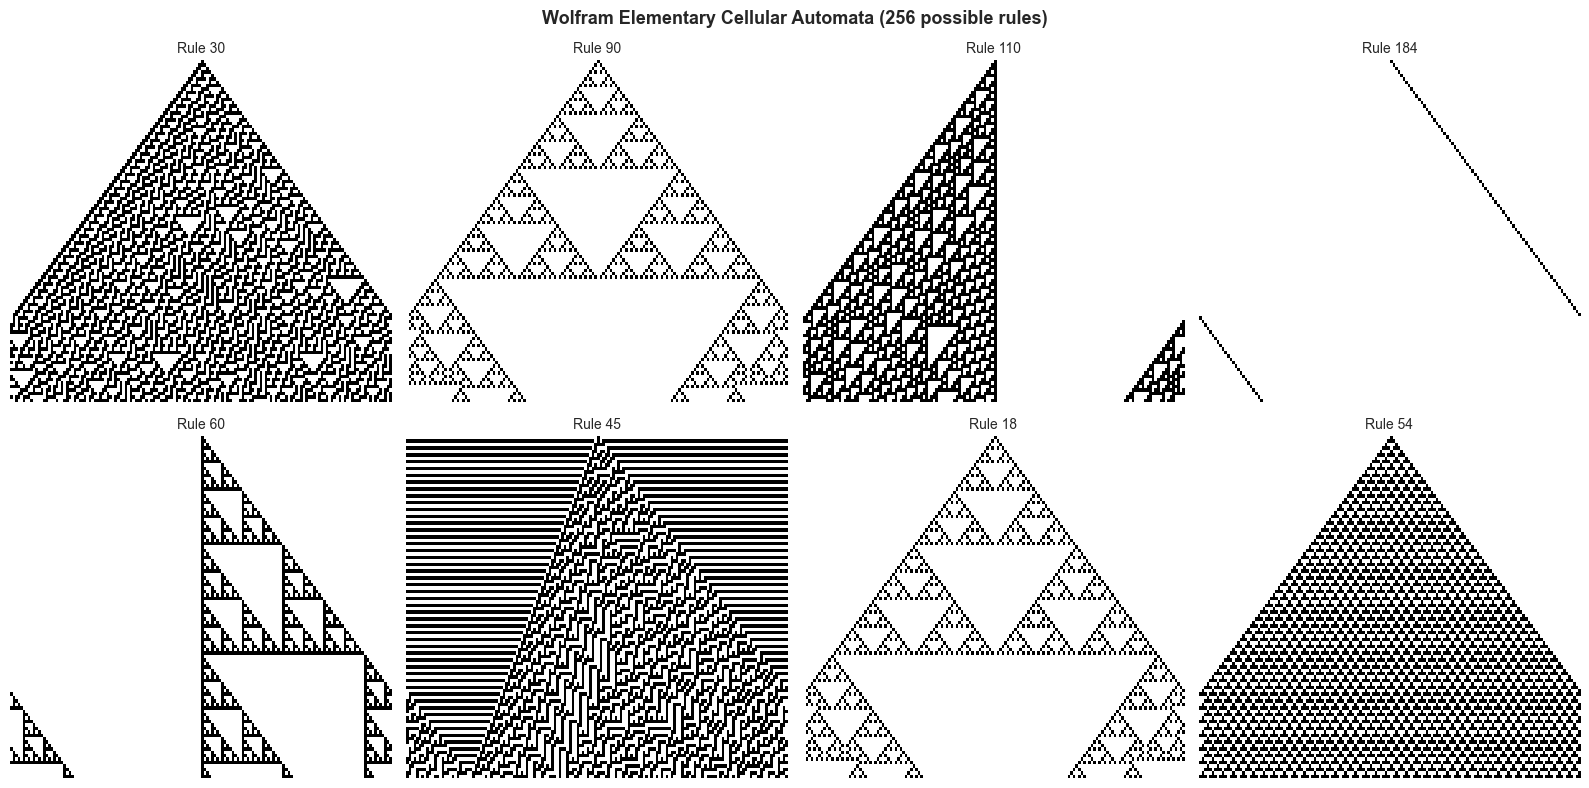

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def apply_rule(state, rule_num):
    """Apply Wolfram elementary CA rule (0-255) to a 1D state."""
    rule = np.array([(rule_num >> i) & 1 for i in range(8)], dtype=np.uint8)
    n = len(state)
    new_state = np.zeros(n, dtype=np.uint8)
    for i in range(n):
        left = state[(i-1) % n]
        center = state[i]
        right = state[(i+1) % n]
        neighborhood = 4*left + 2*center + right
        new_state[i] = rule[neighborhood]
    return new_state

def run_ca_1d(rule_num, n_cells=150, n_steps=100, seed_single=True):
    """Run 1D CA for n_steps. Start with single cell or random."""
    grid = np.zeros((n_steps, n_cells), dtype=np.uint8)
    if seed_single:
        grid[0, n_cells//2] = 1
    else:
        np.random.seed(0)
        grid[0] = np.random.randint(0, 2, n_cells)
    for t in range(1, n_steps):
        grid[t] = apply_rule(grid[t-1], rule_num)
    return grid

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
rules = [30, 90, 110, 184, 60, 45, 18, 54]
for ax, rule in zip(axes.flat, rules):
    grid = run_ca_1d(rule)
    ax.imshow(grid, cmap='binary', aspect='auto', interpolation='nearest')
    ax.set_title(f'Rule {rule}', fontsize=10); ax.axis('off')

plt.suptitle('Wolfram Elementary Cellular Automata (256 possible rules)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Conway's Game of Life

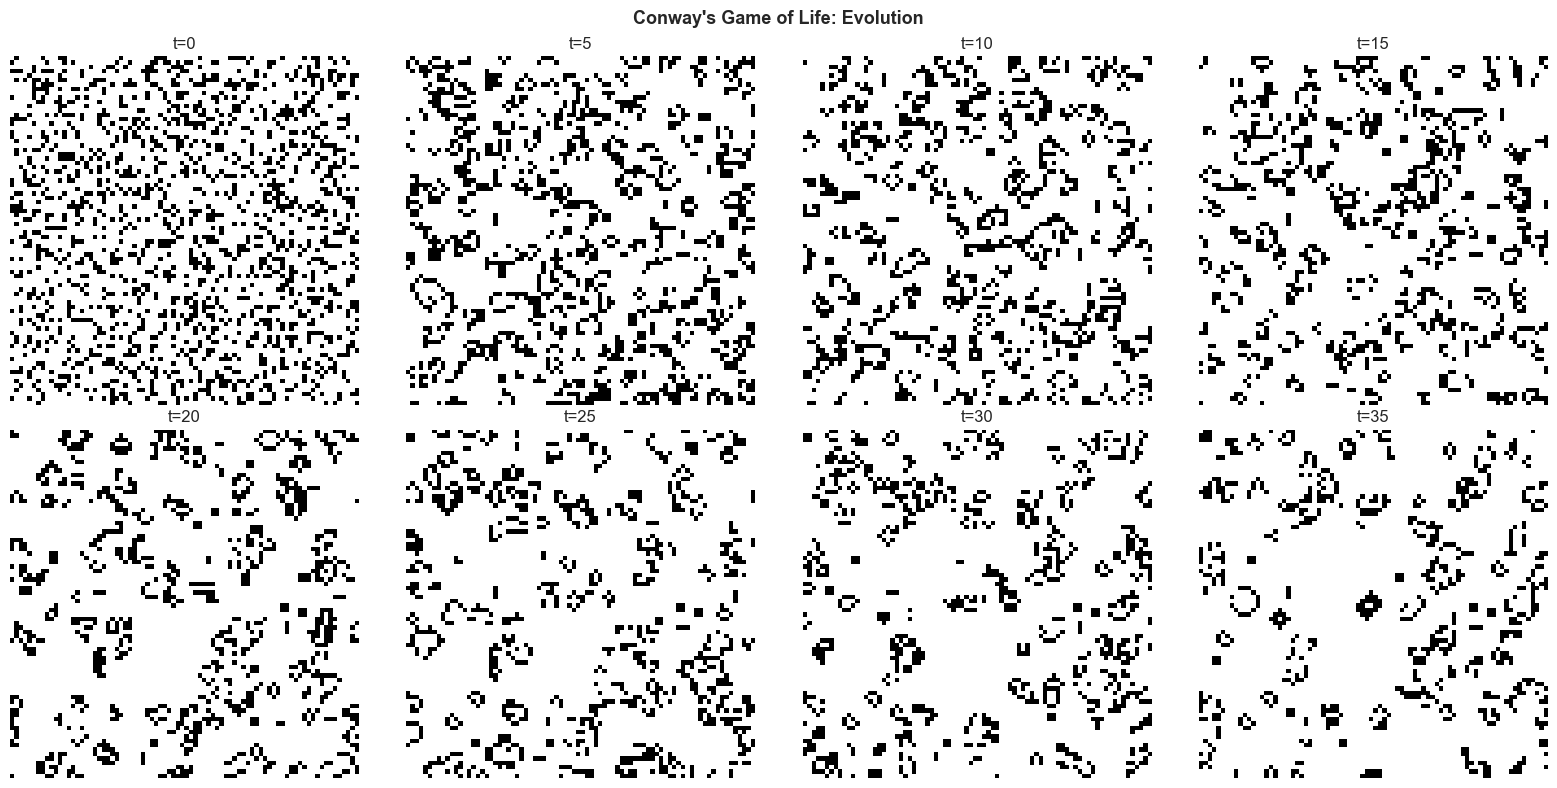

In [2]:
# Conway's Game of Life: 2D CA with 4 rules
# 1. Underpopulation: live cell < 2 neighbors → dies
# 2. Survival: live cell 2-3 neighbors → lives
# 3. Overpopulation: live cell > 3 neighbors → dies
# 4. Reproduction: dead cell == 3 neighbors → becomes alive

def gol_step(grid):
    """One step of Conway's Game of Life."""
    from scipy.signal import convolve2d
    kernel = np.ones((3,3), dtype=int); kernel[1,1] = 0
    # Count neighbors using convolution (manual if scipy unavailable)
    # Manual version:
    neighbors = np.zeros_like(grid, dtype=int)
    rows, cols = grid.shape
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0: continue
            neighbors += np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
    
    new_grid = np.zeros_like(grid)
    # Survival
    new_grid[(grid == 1) & ((neighbors == 2) | (neighbors == 3))] = 1
    # Reproduction
    new_grid[(grid == 0) & (neighbors == 3)] = 1
    return new_grid

# Initialize with glider and random region
np.random.seed(42)
SIZE = 80
grid = (np.random.random((SIZE, SIZE)) > 0.75).astype(int)
# Add glider
glider = [(0,1),(1,2),(2,0),(2,1),(2,2)]
for r, c in glider:
    grid[5+r, 5+c] = 1

n_frames = 8
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
current = grid.copy()
for ax, _ in zip(axes.flat, range(n_frames)):
    ax.imshow(current, cmap='binary', interpolation='nearest')
    ax.set_title(f't={_*5}'); ax.axis('off')
    for __ in range(5):
        current = gol_step(current)

plt.suptitle("Conway's Game of Life: Evolution", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 3 — Population Analysis

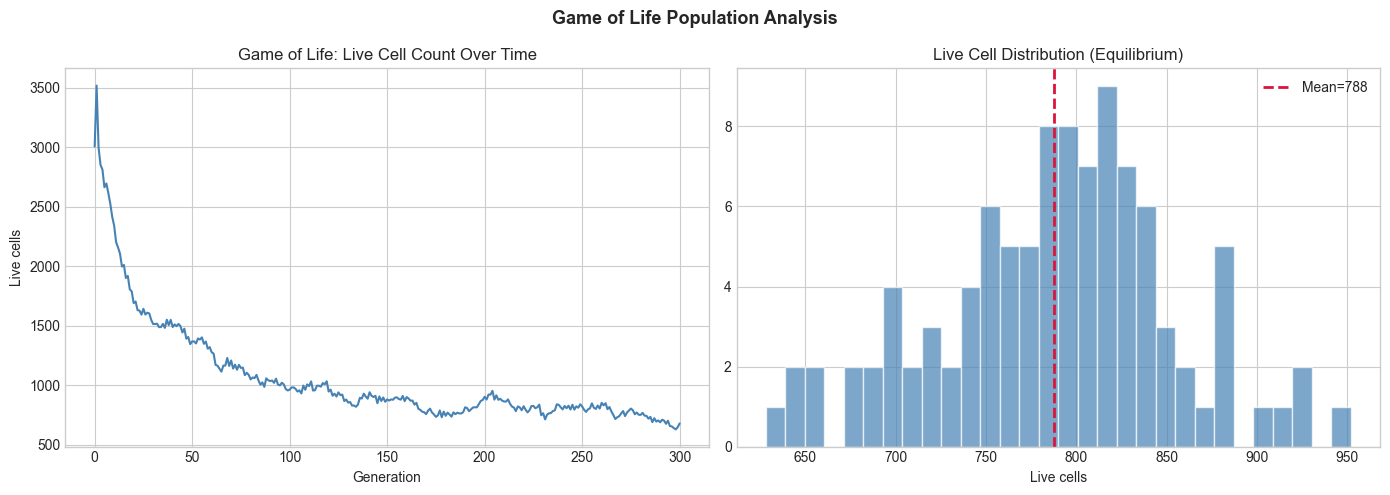

In [3]:
# Track live cell count over time in Game of Life
np.random.seed(7)
SIZE = 100
grid = (np.random.random((SIZE, SIZE)) > 0.7).astype(int)

populations = [grid.sum()]
for _ in range(300):
    grid = gol_step(grid)
    populations.append(grid.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(populations, color='steelblue', linewidth=1.5)
axes[0].set_title("Game of Life: Live Cell Count Over Time")
axes[0].set_xlabel('Generation'); axes[0].set_ylabel('Live cells')

# Equilibrium analysis
tail = populations[200:]
axes[1].hist(tail, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(tail), color='crimson', linestyle='--', linewidth=2, label=f'Mean={np.mean(tail):.0f}')
axes[1].set_title('Live Cell Distribution (Equilibrium)')
axes[1].set_xlabel('Live cells'); axes[1].legend()
plt.suptitle('Game of Life Population Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Wolfram's 256 elementary CA rules, Conway's Game of Life simulator, and population equilibrium analysis.

**Extensions:** 1) Find still lifes, oscillators, and spaceships in GoL. 2) Implement Brian's Brain (3-state CA). 3) Apply CA to forest fire modeling.